In [1]:
# import necessary libraries
import os
import pandas as pd

# this function loads the dataset by matching each image with its label file
# the label file is stored in a .txt file with the same name as the image
def load_dataset(image_dir, label_dir):
    data = []

    # loop through all files inside the image folder
    for img_name in os.listdir(image_dir):
        
        # only proces image files
        if img_name.endswith((".jpg", ".png", ".jpeg")):
            
            # create full path for the image
            img_path = os.path.join(image_dir, img_name)

            # replace the image extension with .txt to find the label file
            label_file = img_name.replace(".jpg", ".txt")
            label_path = os.path.join(label_dir, label_file)

            # only add the image if the label file exists
            if os.path.exists(label_path):
                
                
                # read the first line of the label file
                # the first value respresents the class ID
                with open(label_path, "r") as f:
                    first_line = f.readline().strip()
                    label = int(first_line.split()[0])  # take only class id

                # store image path and label together
                data.append({
                    "image_path": img_path,
                    "label": label
                })
                
                

                
    # convert everything into a pandas DataFrame            
    return pd.DataFrame(data)


In [2]:
# load training dataset
train_df = load_dataset(
    "/Users/stephaniekeziah/Desktop/bcdd/train/images",
    "/Users/stephaniekeziah/Desktop/bcdd/train/labels"
)

# load testing dataset
test_df = load_dataset(
    "/Users/stephaniekeziah/Desktop/bcdd/test/images",
    "/Users/stephaniekeziah/Desktop/bcdd/test/labels"
)

# display first few rows to check if data loaded correctly
print(train_df.head())

# check how many samples exist for each class
print(train_df["label"].value_counts())


                                          image_path  label
0  /Users/stephaniekeziah/Desktop/bcdd/train/imag...      1
1  /Users/stephaniekeziah/Desktop/bcdd/train/imag...      1
2  /Users/stephaniekeziah/Desktop/bcdd/train/imag...      1
3  /Users/stephaniekeziah/Desktop/bcdd/train/imag...      1
4  /Users/stephaniekeziah/Desktop/bcdd/train/imag...      1
label
1    1278
0     230
Name: count, dtype: int64


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# image size used for training - same size required for VGG16
IMG_SIZE = (224, 224)

# number of images processed in one batch
BATCH_SIZE = 16

# labels must be converted to string because flow_from_dataframe expects strong labels
train_df["label"] = train_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

# data augmentation for training dataset
# helps to improve model generalisation and reduce overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

# only rescaling is applied to the test dataset
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# convert DataFrame into training generator
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

# convert DataFrame into testing generator
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False # keep order fixed for evaluation
)


Found 1508 validated image filenames belonging to 2 classes.
Found 72 validated image filenames belonging to 2 classes.


VGG16

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# import necessary libraries
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# load pre-trained VGG16 model without the fully connected top layers
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# freeze all convolution layers so that only the new layers are trained
for layer in base_model.layers:
    layer.trainable = False

In [5]:
# add custom classification layers on top of VGG16
x = base_model.output
x = GlobalAveragePooling2D()(x) # reduce feature map to a single vector
x = Dense(256, activation="relu")(x) # fully connected layer
x = Dropout(0.5)(x) # reduce overfitting
output = Dense(1, activation="sigmoid")(x) # binary classification output

# create the final model
model = Model(inputs=base_model.input, outputs=output)


In [6]:
# compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# display the model architecture
model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
# train the model using the training generator
# validation is done using the test generator to monitor performance
history = model.fit(
    train_gen,
    epochs=8,
    validation_data=test_gen
)

# save the trained model so it can be reused later without retraining
model.save("bcdd_vgg16_model.h5")


Epoch 1/8
95/95 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8580 - loss: 0.3429 - val_accuracy: 0.8472 - val_loss: 0.3454
Epoch 2/8
95/95 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8567 - loss: 0.3420 - val_accuracy: 0.8472 - val_loss: 0.3386
Epoch 3/8
95/95 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8518 - loss: 0.3488 - val_accuracy: 0.8611 - val_loss: 0.3341
Epoch 4/8
95/95 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8770 - loss: 0.3194 - val_accuracy: 0.8611 - val_loss: 0.3239
Epoch 5/8
95/95 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8826 - loss: 0.3083 - val_accuracy: 0.8611 - val_loss: 0.3212
Epoch 6/8
95/95 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8841 - loss: 0.3110 - val_accuracy: 0.8611 - val_loss: 0.3131
Epoch 7/8
95/95 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8908 - loss: 0.3136 - val_accuracy: 0.8611 - val_loss: 0.3152
Epoch 8/8
95/95 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8927 - loss: 0.3109 - val_accuracy: 0.8611 - val_loss:

# Model Evaluation
Accuracy and Loss curves

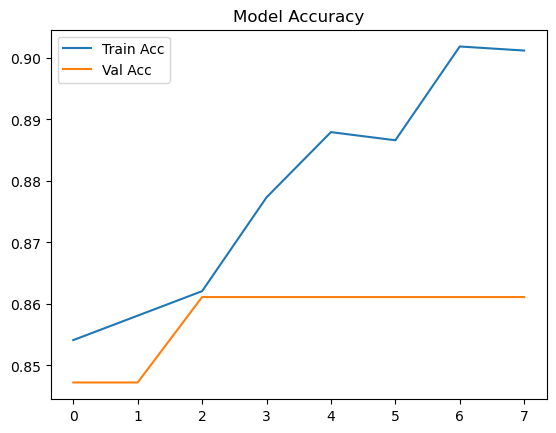

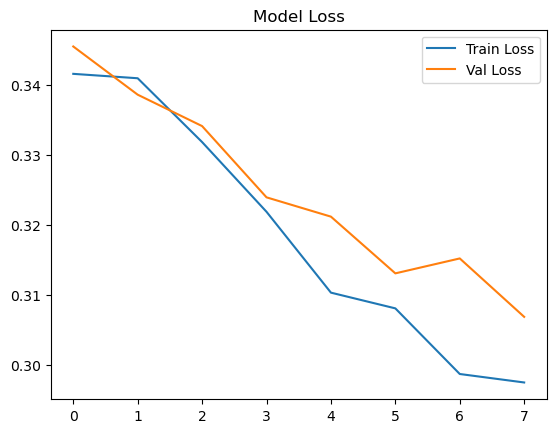

In [9]:
import matplotlib.pyplot as plt

# plot training accuracy vs validation accuracy
# this helps to check if the model is overfitting or learning properly
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Model Accuracy")
plt.show()

# plot training loss vs validation loss
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Model Loss")
plt.show()


AUC, F1-score

In [10]:
from sklearn.metrics import classification_report, roc_auc_score

# true labels from test generator
y_true = test_gen.classes

# model predictions - probability values
y_pred = model.predict(test_gen)

# convert probabilities into binary values - 0 or 1
y_pred_bin = (y_pred > 0.5).astype(int)

#display precision, recall, f1-score and accuracy
print(classification_report(y_true, y_pred_bin))

# calculate AUC score to evaluate classification performance
print("AUC:", roc_auc_score(y_true, y_pred))


5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
              precision    recall  f1-score   support

           0       1.00      0.09      0.17        11
           1       0.86      1.00      0.92        61

    accuracy                           0.86        72
   macro avg       0.93      0.55      0.55        72
weighted avg       0.88      0.86      0.81        72

AUC: 0.8599105812220567


### Grad-CAM

In [14]:
import tensorflow as tf
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# function to generate Grad-CAM heatmap
# Grad-CAM helps to visualise which part of the image the model focuses on
def grad_cam(img_path, model, last_conv_layer_name="block5_conv3"):
    
    # load and resize image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    
    # normalise image
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    #create a model that outputs both feature maps and predictions
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    
    # take average of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    # generate heatmap
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)[0]
    #normalize heatmap
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    
    return heatmap, img


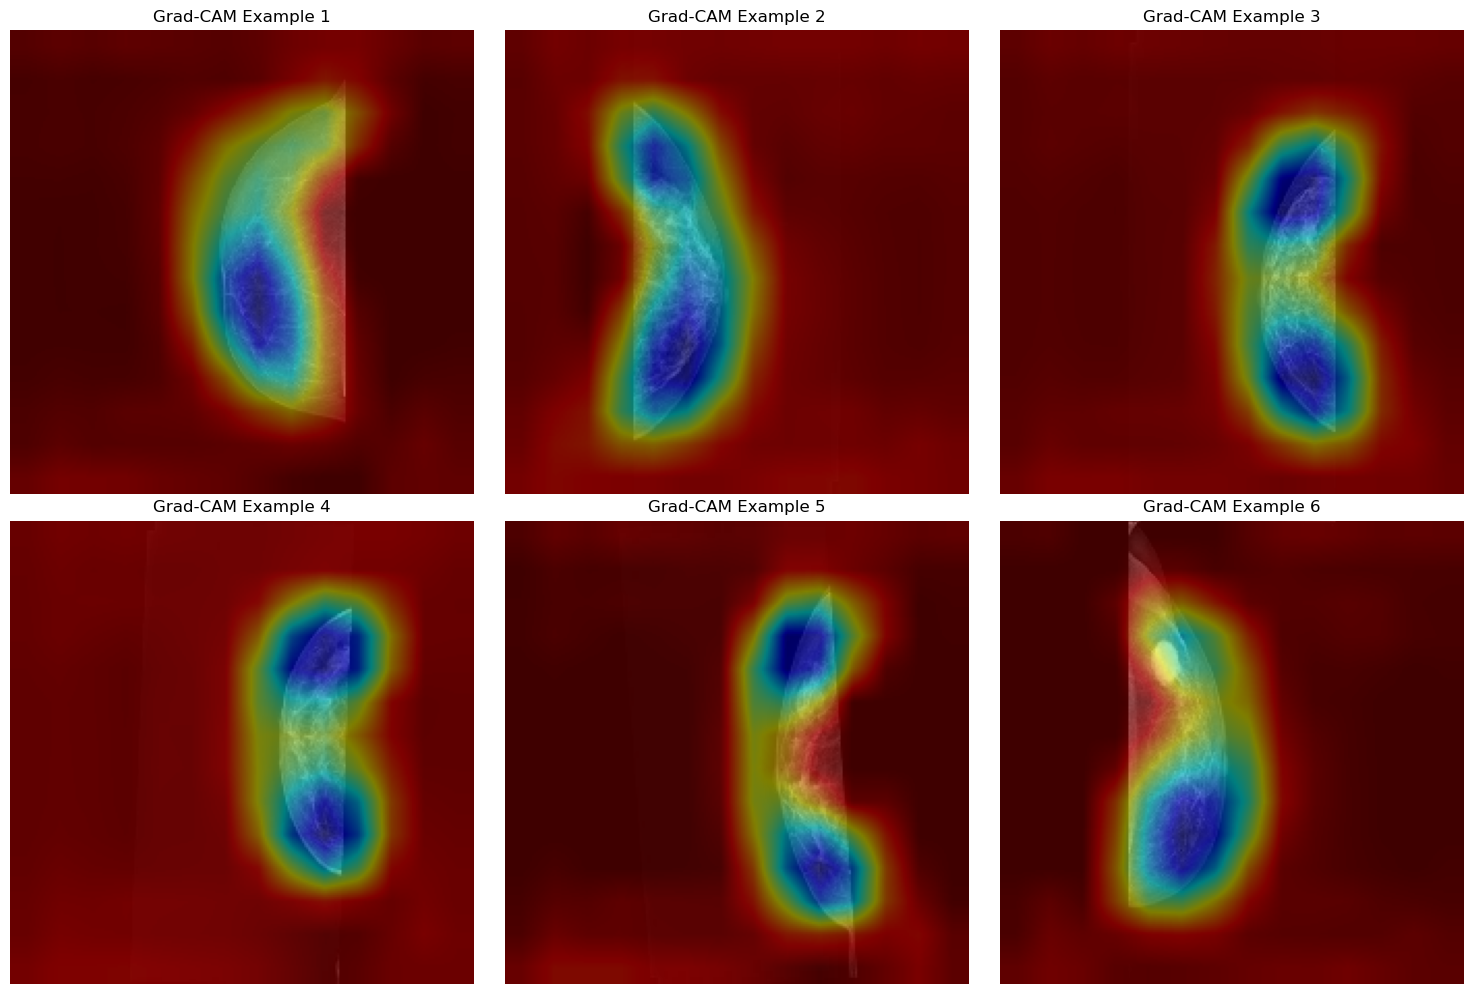

In [15]:
# display Grad-CAM results for multiple images
plt.figure(figsize=(15,10))

for i in range(6):
    img_path = train_df.iloc[i]["image_path"]

    heatmap, img = grad_cam(img_path, model)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    plt.subplot(2,3,i+1)     # 2 rows, 3 columns
    plt.imshow(img)
    plt.imshow(heatmap, alpha=0.5) #overlay heatmap on original image
    plt.axis("off")
    plt.title(f"Grad-CAM Example {i+1}")

plt.tight_layout()
plt.show()


LIME

In [19]:
!pip install lime


In [20]:
# import necessary libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries


In [21]:
IMG_SIZE = (224, 224)

# function to load image for LIME explanation
def load_image_for_lime(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    return img


In [22]:
# function used by LIME to get model predictions
def predict_fn(images):
    images = np.array(images)
    images = images / 255.0  # same normalization as training
    preds = model.predict(images)
    
    # convert output into 2-class probability format [prob_class0, prob_class1]
    return np.hstack([1 - preds, preds])


In [23]:
img_path = test_df.iloc[0]["image_path"]
image = load_image_for_lime(img_path)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 804ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 804ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 818ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 800ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 787ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 810ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 790ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

  0%|          | 0/1000 [00:00<?, ?it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 787ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 779ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 779ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 859ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

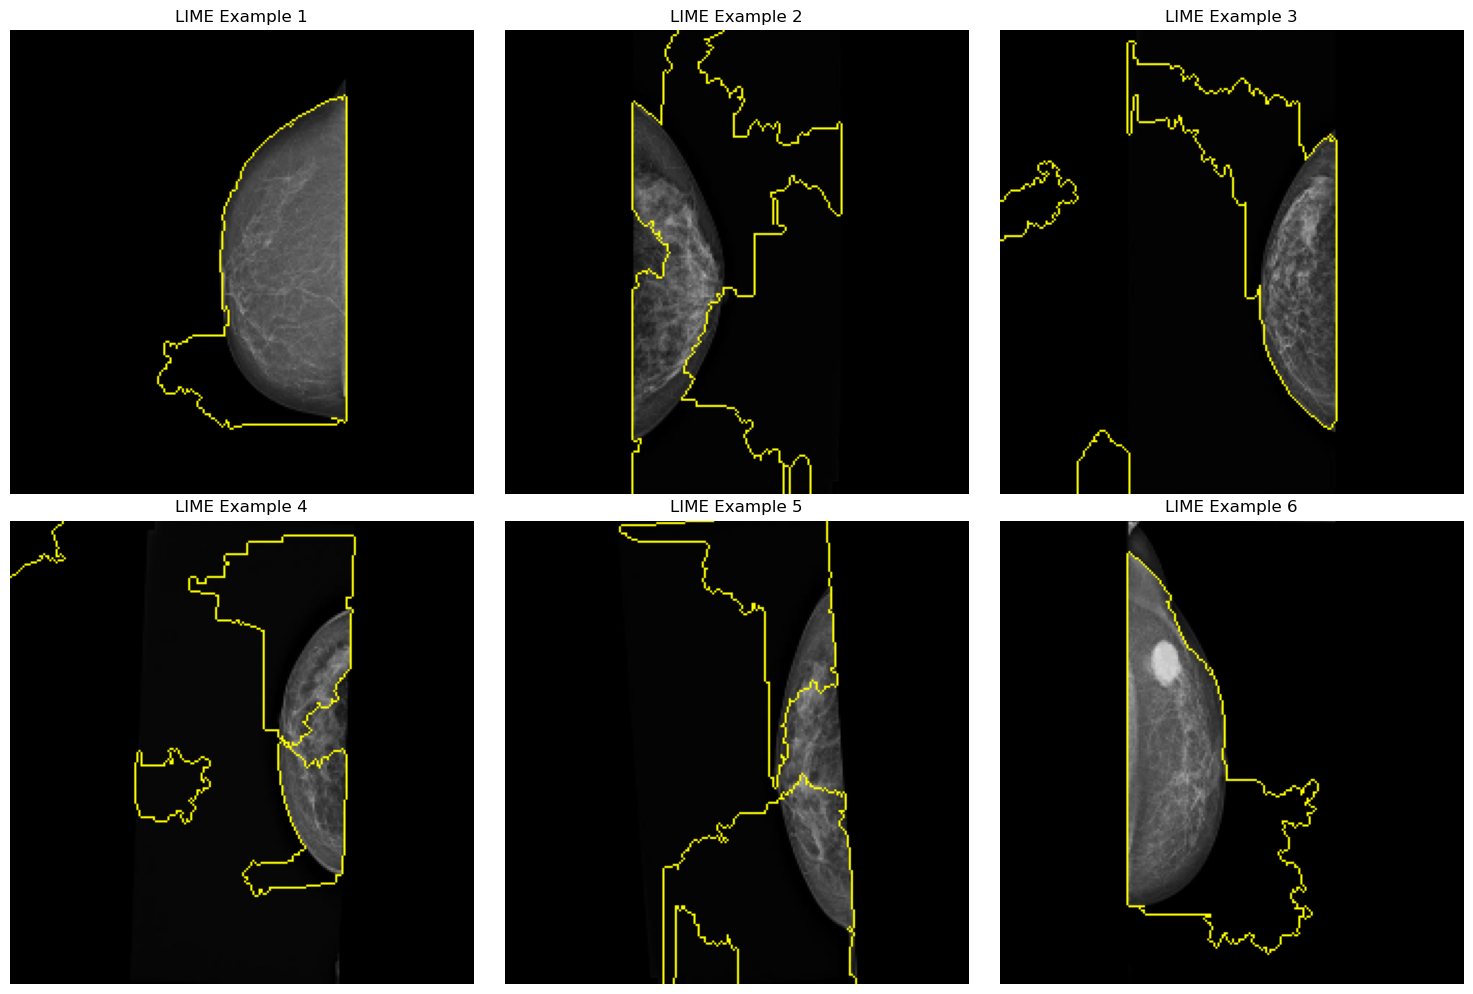

In [24]:
# create LIME explainer
explainer = lime_image.LimeImageExplainer()

plt.figure(figsize=(15,10))

for i in range(6):   # display multiple explanation examples
    img_path = train_df.iloc[i]["image_path"]

    # load image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # generate LIME explanation
    explanation = explainer.explain_instance(
        img,
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    # highlight most important regions of image
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    plt.subplot(2,3,i+1)
    plt.imshow(mark_boundaries(temp, mask))
    plt.axis("off")
    plt.title(f"LIME Example {i+1}")

plt.tight_layout()
plt.show()